In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report

In [2]:
df = pd.read_csv("cancer_risk_dataset.csv")
df.head(4)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Cancer_Type              2000 non-null   object 
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Hazards     2000 non-null   int64  
 14  BRCA_Mutation           

# Existe desbalance de clases

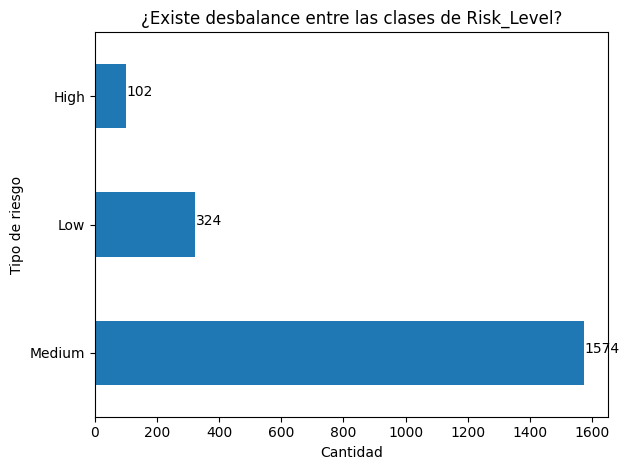

In [4]:
df.Risk_Level.value_counts().plot.barh()
plt.title("¿Existe desbalance entre las clases de Risk_Level?")

for i, val in enumerate(df.Risk_Level.value_counts().values) : 
    plt.text(val, i, val)
plt.ylabel("Tipo de riesgo")
plt.xlabel("Cantidad")
plt.tight_layout()

Durante el entrenamiento del modelo crearemos data para las clases minoría con SMOTE

# Mapa de correlación

<Axes: >

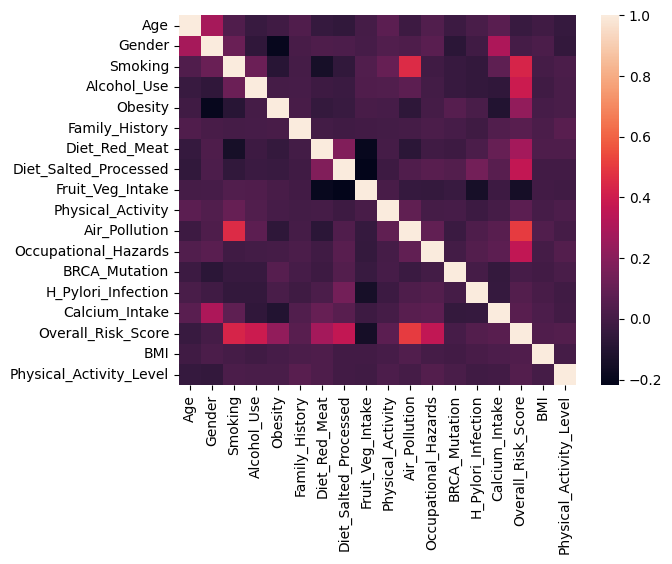

In [7]:
sns.heatmap(df.select_dtypes(["int64", "float64"]).corr())

# Entrenamiento del modelo

In [115]:
X = df[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]
Y = df.Risk_Level

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [116]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

In [39]:
rf.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Evaluación del modelo

Evaluación del modelo en general

In [40]:
pred = rf.predict(X_test)
print(accuracy_score(Y_test, pred))

0.86


Existe desbalance de clases, evaluemos qué tan bien predice el modelo a la clase de riesgo High

Idea: Solo tomaremos los valores de X_test cuyo risk sea "High", y luego los pasaremos a predecir para ver los resultados

In [41]:
high = df[df["Risk_Level"] == "High"]


In [42]:
indexes = X_test.index.values
dropped = []
for i in high.index.values:
    if(i not in indexes):
        dropped.append(i)

X_test_high = high.drop(dropped)
X_test_high = X_test_high[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]


In [144]:
print(classification_report(Y_test, pred))

              precision    recall  f1-score   support

        High       0.33      0.06      0.11        16
         Low       0.70      0.54      0.61        57
      Medium       0.88      0.95      0.92       327

    accuracy                           0.86       400
   macro avg       0.64      0.52      0.55       400
weighted avg       0.84      0.86      0.84       400



In [43]:

pred2 = rf.predict(X_test_high)
print(accuracy_score(high["Risk_Level"].drop(dropped), pred2))

0.0625


La predicción es muy mala, predice a la mayoría como "Medium"

# Entrenamiento de Random Forest con pesos (class weights)

In [145]:
weights = {'High':10, 'Low':.5, 'Medium':.1}

In [146]:
X = df[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]
Y = df.Risk_Level

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [147]:
rf_weight = RandomForestClassifier(n_estimators=200, random_state=42, class_weight=weights)

In [148]:
rf_weight.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [149]:
pred_w = rf_weight.predict(X_test)
print(accuracy_score(Y_test, pred_w))

0.855


In [150]:
print(classification_report(Y_test, pred_w))

              precision    recall  f1-score   support

        High       0.57      0.25      0.35        16
         Low       0.68      0.47      0.56        57
      Medium       0.88      0.95      0.91       327

    accuracy                           0.85       400
   macro avg       0.71      0.56      0.61       400
weighted avg       0.84      0.85      0.84       400



In [151]:
print(f1_score(Y_test, pred_w, average="macro"))

0.6064110000790993


# Entrenamiento de un modelo usando los datos creados con SMOTE

In [111]:
X = df[["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]
Y = df.Risk_Level

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_high, Y_train_high = smote.fit_resample(X_train, Y_train)
X_train_sm, Y_train_sm = smote.fit_resample(X_train_high, Y_train_high)


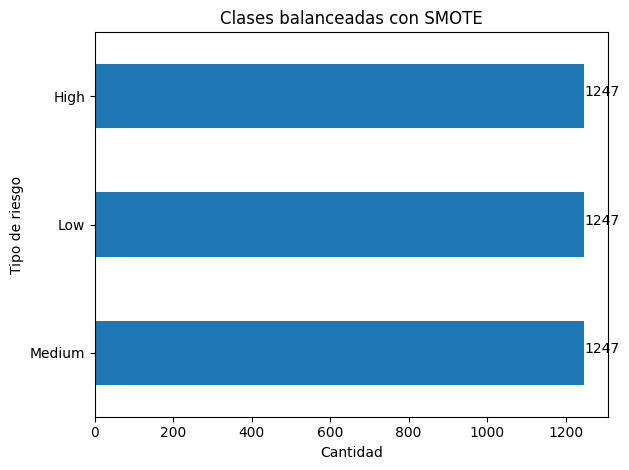

In [112]:
Y_train_sm.value_counts().plot.barh()

plt.title("Clases balanceadas con SMOTE")

for i, val in enumerate(Y_train_sm.value_counts().values) : 
    plt.text(val, i, val)
plt.ylabel("Tipo de riesgo")
plt.xlabel("Cantidad")
plt.tight_layout()

In [79]:
rf_balanced = RandomForestClassifier(n_estimators=200, random_state=42)

In [80]:
rf_balanced.fit(X_train_sm, Y_train_sm)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
print(f1_score(Y_test, pred3, average="macro"))

0.605032854652417


In [103]:
from sklearn.model_selection import cross_val_score

In [104]:
rf_val = RandomForestClassifier(n_estimators=200, random_state=42)

In [114]:

scores = cross_val_score(rf_val, X_train_sm, Y_train_sm, cv=10)

print(f"Mean Accuracy: {scores.mean():.2f}")
print(f"Standard Deviation: {scores.std():.2f}")

Mean Accuracy: 0.95
Standard Deviation: 0.02


Sigue prediciendo mal la clase High (pero no tan mal como antes)

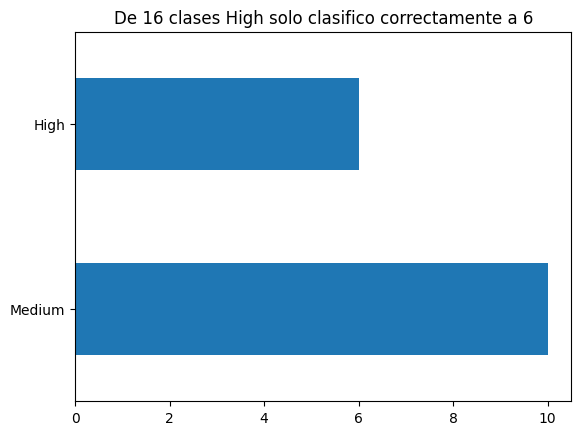

In [83]:
pd.Series(pred2).value_counts().plot.barh()
plt.title("De 16 clases High solo clasifico correctamente a 6")
plt.show()

In [84]:
a = X_train_sm
a["Y"] = Y_train_sm


In [85]:
a[a["Y"] == "Medium"][["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]

,Air_Pollution,Smoking,Alcohol_Use,Occupational_Hazards,Diet_Salted_Processed,Obesity,Diet_Red_Meat
0,6,6,0,7,6,1,10
1,10,4,0,8,2,7,0
2,1,6,8,1,3,8,7
3,3,0,10,3,2,0,10
5,8,2,7,5,4,6,8
...,...,...,...,...,...,...,...
1594,8,8,8,5,1,0,5
1595,4,4,8,10,4,4,1
1596,6,6,3,6,3,4,4
1598,3,5,4,2,4,8,7


In [60]:
df[df["Risk_Level"] == "High"][["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]

,Air_Pollution,Smoking,Alcohol_Use,Occupational_Hazards,Diet_Salted_Processed,Obesity,Diet_Red_Meat
6,10,10,10,9,4,0,9
24,7,9,8,9,8,8,2
38,8,7,9,10,4,5,5
65,8,7,7,7,6,6,10
74,8,9,7,10,3,10,8
...,...,...,...,...,...,...,...
1913,6,3,7,10,4,5,7
1925,4,10,10,10,5,6,1
1966,6,9,8,9,1,5,7
1984,10,10,5,5,10,7,4


In [62]:
a[a["Y"] == "High"][["Air_Pollution", "Smoking", "Alcohol_Use", "Occupational_Hazards", "Diet_Salted_Processed", "Obesity", "Diet_Red_Meat"]]

,Air_Pollution,Smoking,Alcohol_Use,Occupational_Hazards,Diet_Salted_Processed,Obesity,Diet_Red_Meat
13,8,5,9,5,7,7,10
19,10,10,1,8,5,10,3
67,8,5,9,5,8,10,8
98,6,6,6,7,8,10,6
110,6,7,6,10,5,10,7
...,...,...,...,...,...,...,...
2756,9,10,6,6,3,6,10
2757,6,6,6,6,8,9,5
2758,9,10,7,0,6,8,10
2759,8,4,8,4,7,7,9


# Columnas con mayor influencia al predecir la clase

<Axes: title={'center': 'Columnas con mayor influencia durante entrenamiento del modelo Random Forest'}>

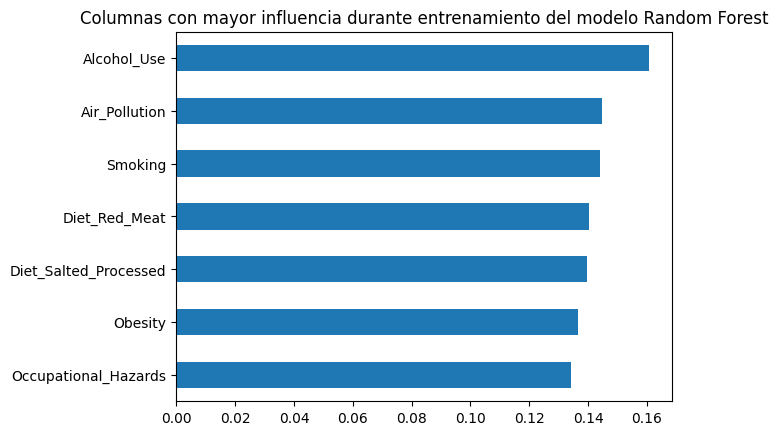

In [61]:
br = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.title("Columnas con mayor influencia durante entrenamiento del modelo Random Forest")
br.plot.barh()

In [87]:
from sklearn.metrics import confusion_matrix

In [92]:
cm = confusion_matrix(high["Risk_Level"], pred)
cm = pd.DataFrame(cm, index=['Actual Negative', 'Actual Positive'], columns= ['Predicted Negative', 'Predicted Positive'])

ValueError: Found input variables with inconsistent numbers of samples: [102, 400]

In [86]:

sns.heatmap(cm, annot=True)

NameError: name 'cm' is not defined